# Langsmith
- LangSmith is a unified observability & evaluation platform where teams can debug, test, & monitor AI app performance
- LangSmith can be used for:
    1. Monitoring - We can monitor based on multiple metrices
    2. Alerting - We can set alerts on specific threshold
    3. Evaluation
    4. Prompt Experimentation
    5. Dataset Creation & Annotation - For Testing your application
    6. User Feedback Integration
    7. Collaboration
    8. Observablity
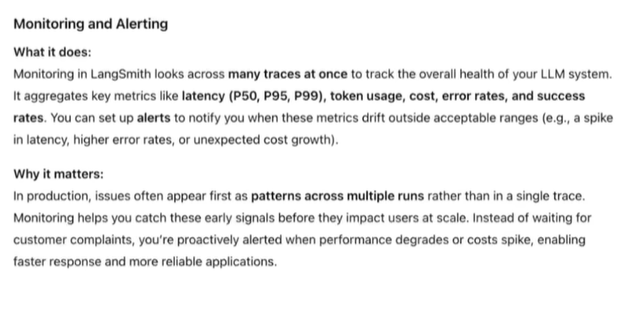
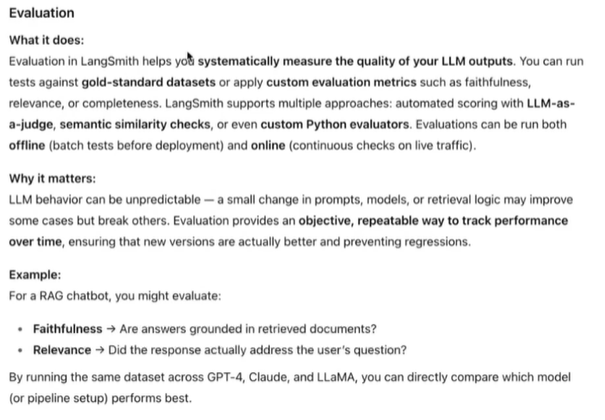
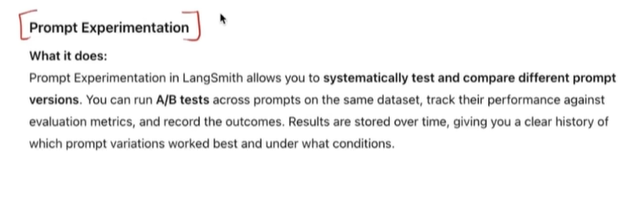
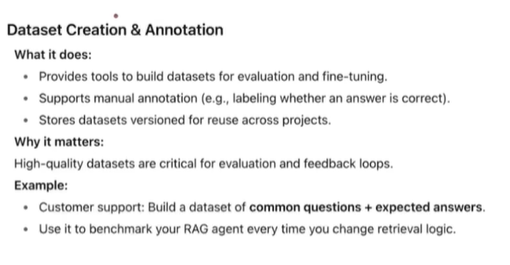
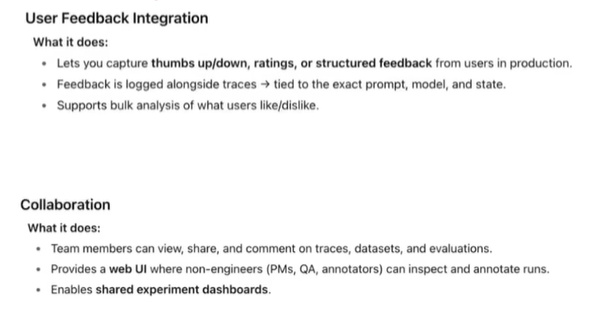


### Observability:
1. It is the ability to understand a system's internal state by examining its external outputs, like logs, metrics, & traces.
2. It allows you to diagnose issues, understand performance, & improve reliability by analyzing data generated by the system.
3. Essentially it's about being able to answer "why" something is happening within a system, even if you didn't anticipate the problem.

### What does LangSmith Trace ?
1. Input & Output
2. All the intermediate steps
3. Latency
4. Token Usage
5. Cost
6. Error
7. Tags
8. Metadata
9. Feedback

### Core Concepts of LangSmith:
1. Project - Any LLM Application flow
2. Trace - One Single workflow execution is called trace
3. Run - LLM application consist of multiple components (i.e. user -> prompt -> LLM -> Parser). Execution through each component is called as run



In [1]:
# Simple LLM Call

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

prompt = PromptTemplate.from_template("{question}")

model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)
parser = StrOutputParser()

chain = prompt | model | parser

result = chain.invoke({"question": "Give me a haiku about the ocean."})
print(result)

d:\Repos\Gen-AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Waves whisper secrets,  
Moon‑lit tide cradles the night,  
Salt breath in silence.


In [2]:
# Sequential Chain with Multiple Prompts

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

model1 = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)
model2 = ChatGoogleGenerativeAI(model='gemini-3-flash-preview', temperature=0.7)

prompt1 = PromptTemplate(
    template='Generate a detailed report on {topic}',
    input_variables=['topic']
)

prompt2 = PromptTemplate(
    template='Generate a 5 pointer summary from the following text \n {text}',
    input_variables=['text']
)

parser = StrOutputParser()
chain = prompt1 | model1 | parser | prompt2 | model2 | parser

config = {
    'tags': ['unemployment', 'india', 'report', 'summary'],
    'metadata': {'model1': model1.model_name, 'model2': model2.model}
}

result = chain.invoke({'topic': 'Unemployment in India'}, config=config)

print(result)

Here is a 5-pointer summary of the report:

1.  **Current Employment Trends:** As of January 2025, India’s national unemployment rate has improved to **6.4%**, down from 7.2% in 2023. However, **youth unemployment (15–29 years)** remains a critical concern at **13.8%**, the highest in the country.
2.  **Demographic and Regional Disparities:** Unemployment is higher among **women (8.9%)** compared to men (5.5%) and more prevalent in **urban areas (7.1%)** than rural ones (5.6%). Regionally, the Northeast (9.1%) and East (8.5%) face the most significant job shortages.
3.  **Structural Challenges:** A staggering **84.2% of the workforce** operates in the informal sector with little job security. Key drivers of unemployment include a **30% skill mismatch** among youth, rapid urbanization, and the lingering effects of global supply-chain shocks.
4.  **Policy Performance and Gaps:** While initiatives like MGNREGA and Skill India provide essential support, they face challenges such as high dr

### Tracing RAG Apps:
- RAG apps have 2 big faliure modes:
    1. Retriever Errors - Wrong or Irrelevant docs retrieved.
    2. Generator Errors - Model hallucinates or misuses context.

- In production, it's often unclear where the faliure happened. Was the retriever bas or did the LLM ignore the docs.

- LangSmith automatically records:
    1. User Query
    2. Retrieved documents
    3. LLM Prompt (with inserted docs)
    4. LLM Response
    

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEmbeddings

PDF_PATH = "../../data/raw/islr.pdf"

# 1) Load PDF
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()

# 2) Chunk
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
splits = splitter.split_documents(docs)

# 3) Embed + index
emb = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vs = FAISS.from_documents(splits, emb)
retriever = vs.as_retriever(search_type="similarity", search_kwargs={"k": 4})

# 4) Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer ONLY from the provided context. If not found, say you don't know."),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

# 5) Chain
def format_docs(docs): return "\n\n".join(d.page_content for d in docs)

parallel = RunnableParallel({
    "context": retriever | RunnableLambda(format_docs),
    "question": RunnablePassthrough()
})

chain = parallel | prompt | model | StrOutputParser()

# 6) Ask questions
print("PDF RAG ready. Ask a question (or Ctrl+C to exit).")
q = input("\nQ: ")
ans = chain.invoke(q.strip())
print("\nA:", ans)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7835.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PDF RAG ready. Ask a question (or Ctrl+C to exit).

A: The book is written by **Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani**.


### Limitations of above RAG Code with respect to Observabiltiy
1. Tracing - We are only processing the final answer as an output, and not the intermediate steps.
2. Latency - We are doingthe same steps in each run: Loading PDF -> Chunking -> retrieving -> LLM (We're not storing the data)

- This makes it difficult to debug or understand where the chain might be failing or producing unexpected results.
- By default Langsmith only trace Langchain runnables

In [ ]:
from langsmith import traceable
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEmbeddings

PDF_PATH = "../../data/raw/islr.pdf"

# Traced setup steps
@traceable(name="load_pdf")
def load_pdf(path: str):
    loader = PyPDFLoader(path)
    return loader.load()

@traceable(name="split_documents")
def split_documents(docs, chunk_size=1000, chunk_overlap=150):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )
    return splitter.split_documents(docs)

@traceable(name="build_vectorstore")
def build_vectorstore(splits):
    emb = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
    vs = FAISS.from_documents(splits, emb)
    return vs

@traceable(name="setup_pipeline")
def setup_pipeline(pdf_path: str):
    docs = load_pdf(pdf_path)
    splits = split_documents(docs)
    vs = build_vectorstore(splits)
    return vs

# Pipeline
llm = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)

prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer ONLY from the provided context. If not found, say you don't know."),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

# Build the index under traced setup
vectorstore = setup_pipeline(PDF_PATH)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

parallel = RunnableParallel({
    "context": retriever | RunnableLambda(format_docs),
    "question": RunnablePassthrough(),
})

chain = parallel | prompt | llm | StrOutputParser()

print("PDF RAG ready. Ask a question (or Ctrl+C to exit).")
q = input("\nQ: ").strip()

config = {"run_name": "pdf_rag_query"}

ans = chain.invoke(q, config=config)
print("\nA:", ans)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1141.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PDF RAG ready. Ask a question (or Ctrl+C to exit).

A: Linear regression is a supervised learning technique used to predict a quantitative (numeric) response variable from one or more predictor variables. It assumes that the relationship between the predictors and the response can be approximated by a straight line (or hyperplane in higher dimensions). The model is fitted by estimating coefficients that minimize the sum of squared differences between the observed responses and those predicted by the linear function (the least‑squares line). This simple, widely‑used method serves as a foundation for more advanced statistical‑learning approaches.


### Limitations:
For the above code each run 2 seperate tracing are created which is not good

In [4]:
from langsmith import traceable
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

PDF_PATH = "../../data/raw/islr.pdf"

# Helpers (not traced individually)
@traceable(name="load_pdf")
def load_pdf(path: str):
    loader = PyPDFLoader(path)
    return loader.load()  # list[Document]

@traceable(name="split_documents")
def split_documents(docs, chunk_size=1000, chunk_overlap=150):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )
    return splitter.split_documents(docs)

@traceable(name="build_vectorstore")
def build_vectorstore(splits):
    emb = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
    return FAISS.from_documents(splits, emb)

# Parent setup function (traced)
@traceable(name="setup_pipeline", tags=["setup"])
def setup_pipeline(pdf_path: str, chunk_size=1000, chunk_overlap=150):
    docs = load_pdf(pdf_path)
    splits = split_documents(docs, chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    vs = build_vectorstore(splits)
    return vs

# Model, prompt, and run
llm = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)

prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer ONLY from the provided context. If not found, say you don't know."),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

# One top-level (root) run
@traceable(name="pdf_rag_full_run")
def setup_pipeline_and_query(pdf_path: str, question: str):
    vectorstore = setup_pipeline(pdf_path, chunk_size=1000, chunk_overlap=150)
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})
    parallel = RunnableParallel({
        "context": retriever | RunnableLambda(format_docs),
        "question": RunnablePassthrough(),
    })

    chain = parallel | prompt | llm | StrOutputParser()

    # This LangChain run stays under the same root (since we're inside this traced function)
    lc_config = {"run_name": "pdf_rag_query"}
    return chain.invoke(question, config=lc_config)

# CLI 
if __name__ == "__main__":
    print("PDF RAG ready. Ask a question (or Ctrl+C to exit).")
    q = input("\nQ: ").strip()
    ans = setup_pipeline_and_query(PDF_PATH, q)
    print("\nA:", ans)

PDF RAG ready. Ask a question (or Ctrl+C to exit).


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1065.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



A: **Summary of the Document**

The passage is an excerpt from a statistics text that illustrates how to use R for data exploration and preprocessing. It includes:

1. **Descriptive Statistics**  
   - Shows example output of `summary()` for numeric variables (e.g., `mpg`) and categorical variables (e.g., car names).  
   - Demonstrates calculation of median, mean, quartiles, and extremes.

2. **Session Management**  
   - Explains how to exit R (`quit()`), save the workspace, and record command history with `savehistory()` and `loadhistory()`.

3. **Key R Functions (Index)**  
   - Provides a quick reference list of functions such as `read.table()`, `summary()`, `rnorm()`, `runif()`, `var()`, `vif()`, `svm()`, `random forest`, `ROC`, etc., with page numbers.

4. **Handling Missing Data**  
   - Uses the `Hitters` dataset from the `ISLR` package as a case study.  
   - Shows how to identify missing values with `is.na()` and count them with `sum()`.  
   - Demonstrates removal of incom